In [2]:
import yfinance as yf

ticker = yf.Ticker("AAPL")
print(ticker.options)

expiry = '2026-06-18'
chain = ticker.option_chain(expiry)
calls = chain.calls
print(calls.head())
print(calls.columns.tolist())

('2026-05-18', '2026-05-20', '2026-05-22', '2026-05-26', '2026-05-27', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-26', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-02-19', '2027-03-19', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')
        contractSymbol             lastTradeDate  strike  lastPrice     bid  \
0  AAPL260618C00005000 2026-05-15 17:11:26+00:00     5.0     297.55  293.45   
1  AAPL260618C00010000 2026-05-08 19:25:04+00:00    10.0     283.39  288.45   
2  AAPL260618C00015000 2026-05-08 19:53:07+00:00    15.0     278.71  283.30   
3  AAPL260618C00020000 2025-05-09 17:16:45+00:00    20.0     178.50  183.05   
4  AAPL260618C00025000 2026-05-11 19:01:45+00:00    25.0     266.37  273.50   

      ask    change  percentChange  volume  openInterest  impliedVolatility  \
0  296.80  4.849976       1.656978       3             0           8.886723   
1  292.20  0.000

In [5]:
import numpy as np
import pandas as pd

expiries = ['2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-12-18', '2027-01-15']

data = []
for expiry in expiries:
    chain = ticker.option_chain(expiry)
    calls = chain.calls
    calls['expiry'] = expiry
    data.append(calls)

df = pd.concat(data)
df = df[['strike', 'impliedVolatility', 'expiry']]
df = df[(df['strike'] >= 100) & (df['strike'] <= 300)]
df = df[df['impliedVolatility'] > 0.01]
print(df.head(10))

    strike  impliedVolatility      expiry
19   100.0           1.703126  2026-06-18
20   105.0           1.584963  2026-06-18
21   110.0           1.518557  2026-06-18
22   115.0           1.418948  2026-06-18
23   120.0           1.417972  2026-06-18
24   125.0           1.359378  2026-06-18
25   130.0           1.312503  2026-06-18
26   135.0           1.229496  2026-06-18
27   140.0           1.302250  2026-06-18
28   145.0           1.179692  2026-06-18


In [6]:
import datetime

today = datetime.date.today()

def days_to_expiry(expiry_str):
    expiry_date = datetime.datetime.strptime(expiry_str, '%Y-%m-%d').date()
    return (expiry_date - today).days / 365

df['T'] = df['expiry'].apply(days_to_expiry)
print(df.head(10))

    strike  impliedVolatility      expiry         T
19   100.0           1.703126  2026-06-18  0.090411
20   105.0           1.584963  2026-06-18  0.090411
21   110.0           1.518557  2026-06-18  0.090411
22   115.0           1.418948  2026-06-18  0.090411
23   120.0           1.417972  2026-06-18  0.090411
24   125.0           1.359378  2026-06-18  0.090411
25   130.0           1.312503  2026-06-18  0.090411
26   135.0           1.229496  2026-06-18  0.090411
27   140.0           1.302250  2026-06-18  0.090411
28   145.0           1.179692  2026-06-18  0.090411


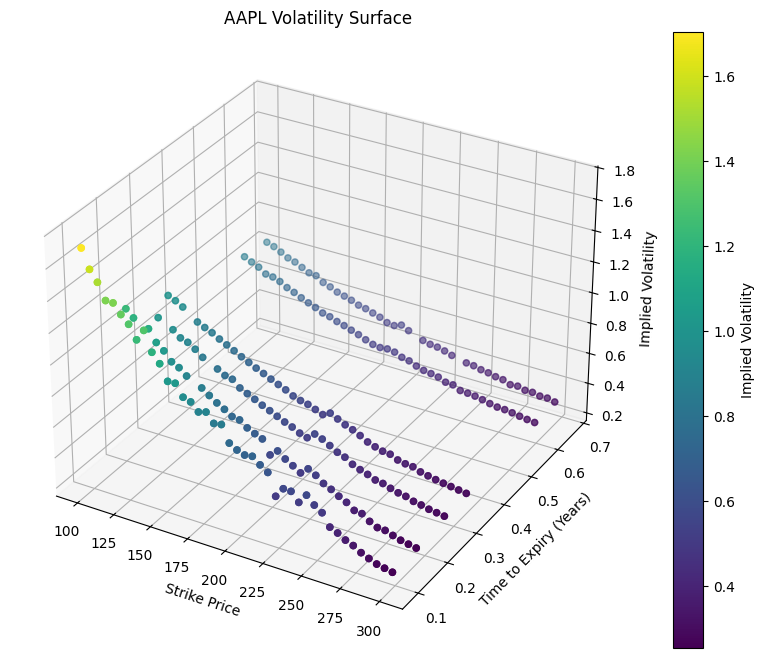

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['strike'], df['T'], df['impliedVolatility'], c=df['impliedVolatility'], cmap='viridis')

ax.set_xlabel('Strike Price')
ax.set_ylabel('Time to Expiry (Years)')
ax.set_zlabel('Implied Volatility')
ax.set_title('AAPL Volatility Surface')
scatter = ax.scatter(df['strike'], df['T'], df['impliedVolatility'], c=df['impliedVolatility'], cmap='viridis')
fig.colorbar(scatter, ax=ax, label='Implied Volatility')
plt.savefig('vol_surface.png', dpi=150, bbox_inches='tight')
plt.show()